#Telco Customer Churn Analysis

##Problem
It is requested to develop a machine learning model to predict customers who are likely to leave the company.

Before building the model, it is expected that the necessary data analysis and feature engineering steps are completed.

##Dataset Information:
The Telco Customer Churn dataset contains information about 7,043 customers who received landline phone and internet services from a fictional telecommunications company operating in California during the third quarter.
It includes information on which customers stayed, left, or signed up for the service.
21 Variables and 7,043 Observations

#Features¶
CustomerID: Customer ID

Gender: Customer's gender

SeniorCitizen: Whether the customer is a senior citizen (1, 0)

Partner: Whether the customer has a partner (Yes, No) — indicates marital status

Dependents: Whether the customer has dependents (Yes, No) — such as children, parents, or grandparents

Tenure: Number of months the customer has stayed with the company

PhoneService: Whether the customer has phone service (Yes, No)

MultipleLines: Whether the customer has multiple lines (Yes, No, No phone service)

InternetService: Customer’s internet service provider (DSL, Fiber optic, No)

OnlineSecurity: Whether the customer has online security service (Yes, No, No internet service)

OnlineBackup: Whether the customer has online backup service (Yes, No, No internet service)

DeviceProtection: Whether the customer has device protection service (Yes, No, No internet service)

TechSupport: Whether the customer has technical support service (Yes, No, No internet service)

StreamingTV: Whether the customer is streaming TV (Yes, No, No internet service) — indicates if they use their internet service to stream TV shows through a third-party provider

StreamingMovies: Whether the customer is streaming movies (Yes, No, No internet service) — indicates if they use their internet service to stream movies through a third-party provider

Contract: Customer's contract term (Month-to-month, One year, Two year)

PaperlessBilling: Whether the customer has paperless billing (Yes, No)

PaymentMethod: Customer's payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))

MonthlyCharges: The amount charged to the customer monthly

TotalCharges: The total amount charged to the customer

Churn: Whether the customer churned (Yes or No) — customers who left within the last month or quarter

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pprint import pprint

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##1.Exploratory data analysis (EDA)

In [3]:
def check_df(dataframe):
    print("##################### Shape #####################")
    print(dataframe.shape)
    print("##################### Types #####################")
    print(dataframe.dtypes)
    print("##################### NA #####################")
    print(dataframe.isnull().sum())
    print("##################### Quantiles #####################")
    print(dataframe.describe())
check_df(df)

##################### Shape #####################
(7043, 21)
##################### Types #####################
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object
##################### NA #####################
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        

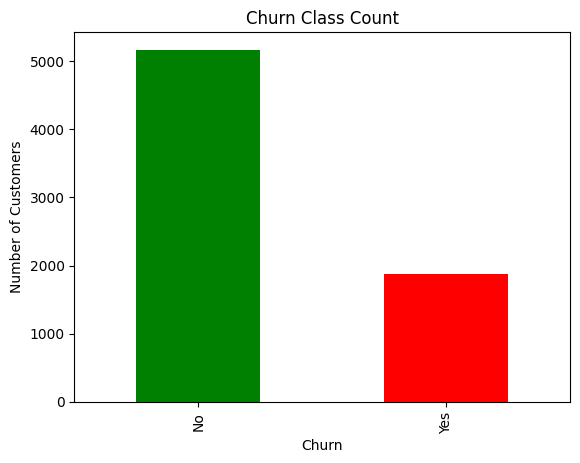

In [4]:
df['Churn'].value_counts().plot(kind='bar',color=['green', 'red'])
plt.title('Churn Class Count')
plt.xlabel('Churn')
plt.ylabel('Number of Customers')
plt.show()


In [5]:
(df['Churn'].value_counts()/len(df['Churn']))*100

,count
Churn,
No,73.463013
Yes,26.536987


In [6]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


###📊 Key Observation
Data is highly imbalanced, ratio = 73:27
So we analyse the data with other features while taking the target values separately to get some insights.

### Data cleaning

In [7]:
 # We need to change the type of the variables TotalCharges and churn
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [8]:
df['Churn']=df['Churn'].apply(lambda x:1 if x=='Yes' else 0)

In [9]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [10]:
df['Churn']

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [11]:
#As we can see there are 11 missing values in TotalCharges column. Let's check these records
df[df['TotalCharges'].isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,0
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,0
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,0
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,0
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,0
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,0
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,0
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,0
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,0
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,0


In [12]:
print((df['TotalCharges'].isnull().sum() / len(df)) * 100)


0.1561834445548772


In [13]:
def grab_col_names(dataframe, num_to_cat_th=10, cat_to_car_th=20):
  #Categorical Variables (cat_cols)
  cat_cols = [col for col in dataframe.columns if dataframe[col].dtypes == "O"]
  #Numerical-looking but Categorical Variables (num_but_cat)
  num_but_cat = [col for col in dataframe.columns if dataframe[col].nunique() < num_to_cat_th and dataframe[col].dtypes != "O"]
  #Categorical-looking but Cardinal Variables (cat_but_car)
  cat_but_car = [col for col in dataframe.columns if dataframe[col].nunique() > cat_to_car_th and dataframe[col].dtypes == "O"]
  #Combining Categorical Variables
  cat_cols = cat_cols + num_but_cat
  cat_cols = [col for col in cat_cols if col not in cat_but_car]
  #Numerical Variables (num_cols)
  num_cols = [col for col in dataframe.columns if dataframe[col].dtypes != "O"]
  num_cols = [col for col in num_cols if col not in num_but_cat]
  print(f"Number of rows: {dataframe.shape[0]}")
  print(f"Number of Variables: {dataframe.shape[1]}")
  print(f'Number of categorical variables: {len(cat_cols)}')
  print(f'Number of numerical variables: {len(num_cols)}')
  print(f'Number of categorical but cardinal variables: {len(cat_but_car)}')
  print(f'Number of numerical-looking categorical variables: {len(num_but_cat)}')
  return cat_cols, num_cols, cat_but_car,num_but_cat
cat_cols, num_cols, cat_but_car,num_but_cat = grab_col_names(df)

# Print the results
print("************ Categorical Variables ************  ")
pprint(cat_cols)
print("************ Numerical Variables ************")
pprint(num_cols)
print("************ Categorical but Cardinal Variables ************")
pprint(cat_but_car)
print("************ Numerical but Categorical Variables ************")
pprint(num_but_cat)


Number of rows: 7043
Number of Variables: 21
Number of categorical variables: 17
Number of numerical variables: 3
Number of categorical but cardinal variables: 1
Number of numerical-looking categorical variables: 2
************ Categorical Variables ************  
['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'SeniorCitizen',
 'Churn']
************ Numerical Variables ************
['tenure', 'MonthlyCharges', 'TotalCharges']
************ Categorical but Cardinal Variables ************
['customerID']
************ Numerical but Categorical Variables ************
['SeniorCitizen', 'Churn']


In [14]:
from pprint import pprint

##1.2 ANALYSIS OF CATEGORICAL VARIABLES

        gender     Ratio
gender                  
Male      3555  50.47565
Female    3488  49.52435


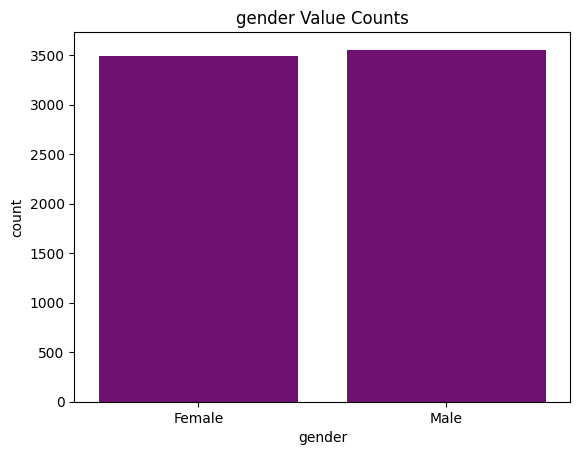

         Partner     Ratio
Partner                   
No          3641  51.69672
Yes         3402  48.30328


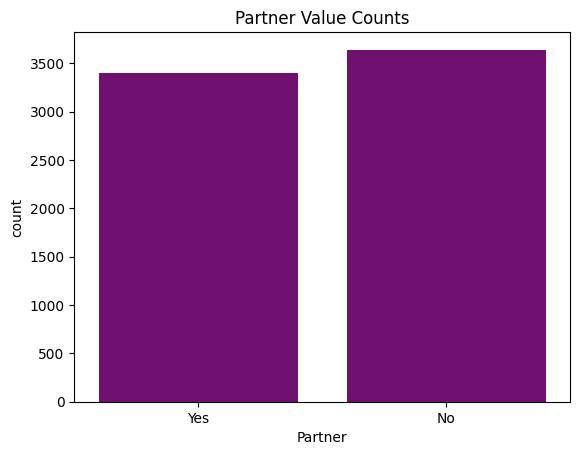

            Dependents      Ratio
Dependents                       
No                4933  70.041176
Yes               2110  29.958824


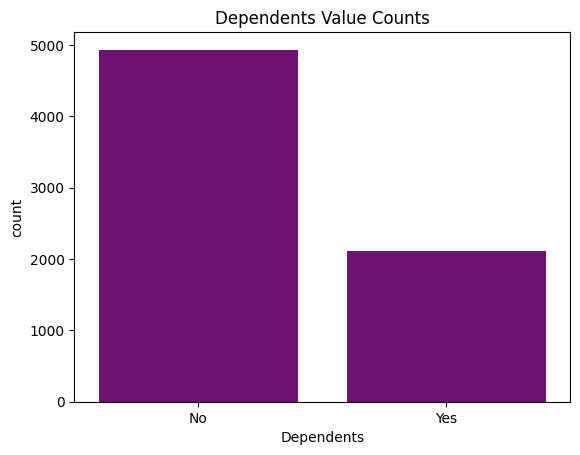

              PhoneService      Ratio
PhoneService                         
Yes                   6361  90.316626
No                     682   9.683374


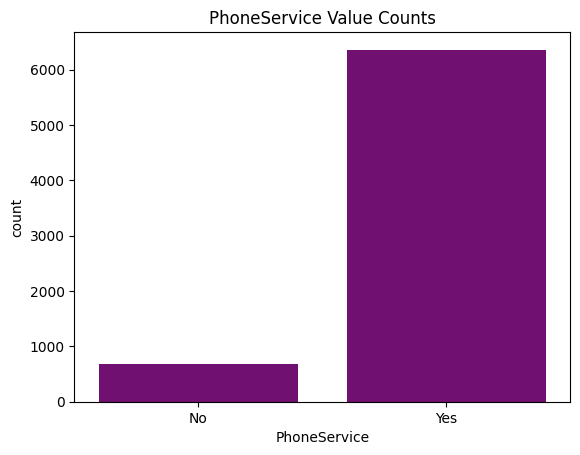

                  MultipleLines      Ratio
MultipleLines                             
No                         3390  48.132898
Yes                        2971  42.183729
No phone service            682   9.683374


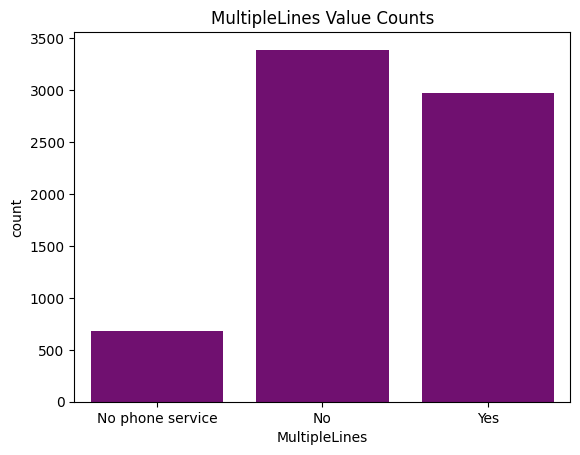

                 InternetService      Ratio
InternetService                            
Fiber optic                 3096  43.958540
DSL                         2421  34.374556
No                          1526  21.666903


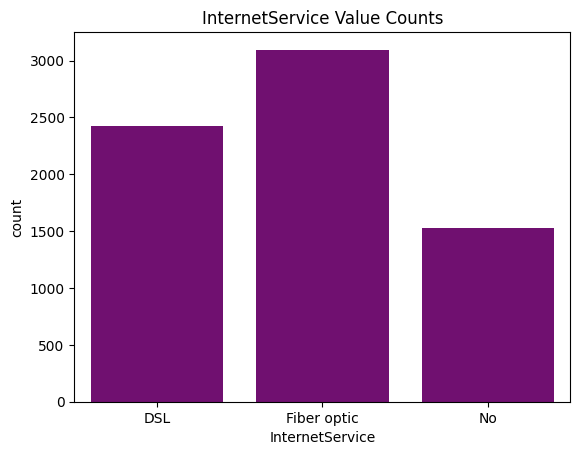

                     OnlineSecurity      Ratio
OnlineSecurity                                
No                             3498  49.666335
Yes                            2019  28.666761
No internet service            1526  21.666903


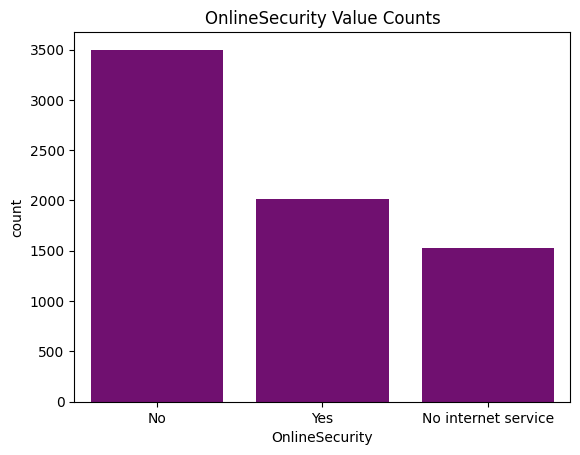

                     OnlineBackup      Ratio
OnlineBackup                                
No                           3088  43.844952
Yes                          2429  34.488144
No internet service          1526  21.666903


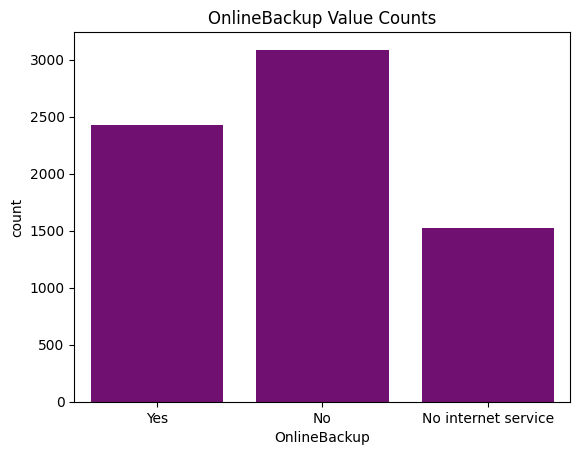

                     DeviceProtection      Ratio
DeviceProtection                                
No                               3095  43.944342
Yes                              2422  34.388755
No internet service              1526  21.666903


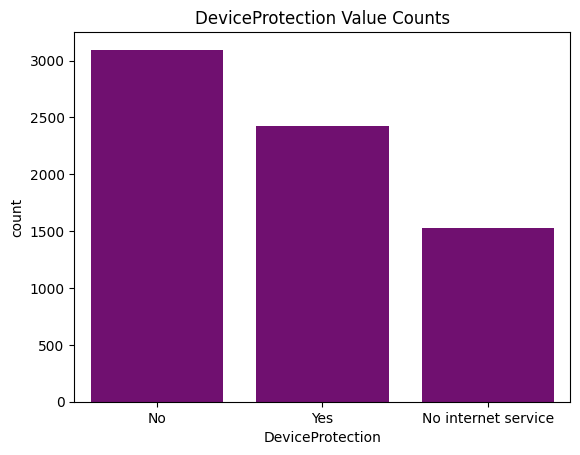

                     TechSupport      Ratio
TechSupport                                
No                          3473  49.311373
Yes                         2044  29.021724
No internet service         1526  21.666903


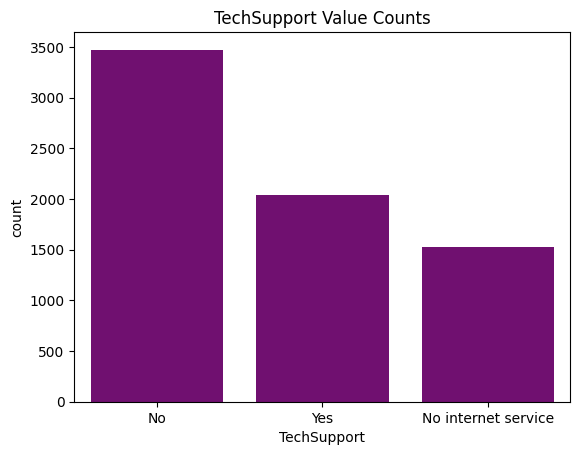

                     StreamingTV      Ratio
StreamingTV                                
No                          2810  39.897771
Yes                         2707  38.435326
No internet service         1526  21.666903


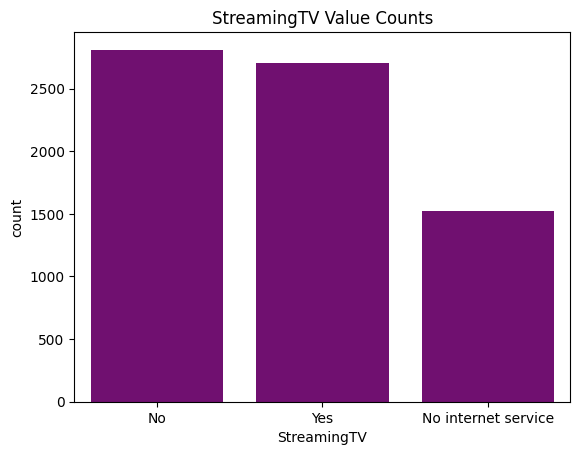

                     StreamingMovies      Ratio
StreamingMovies                                
No                              2785  39.542808
Yes                             2732  38.790288
No internet service             1526  21.666903


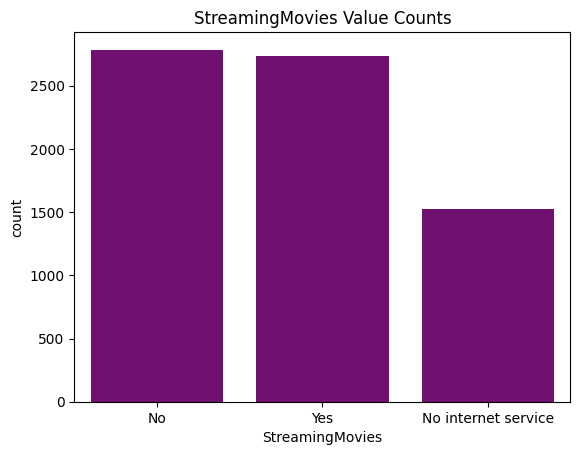

                Contract      Ratio
Contract                           
Month-to-month      3875  55.019168
Two year            1695  24.066449
One year            1473  20.914383


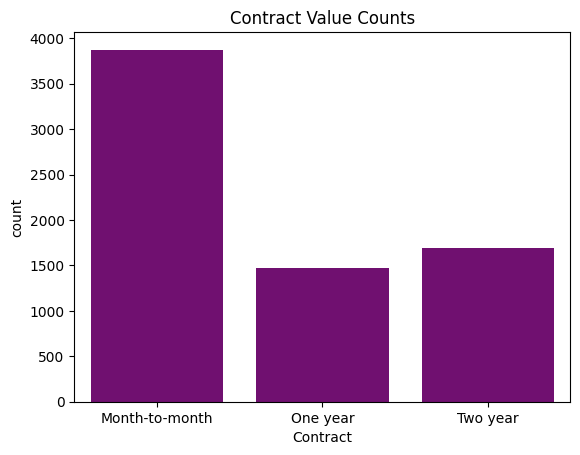

                  PaperlessBilling      Ratio
PaperlessBilling                             
Yes                           4171  59.221922
No                            2872  40.778078


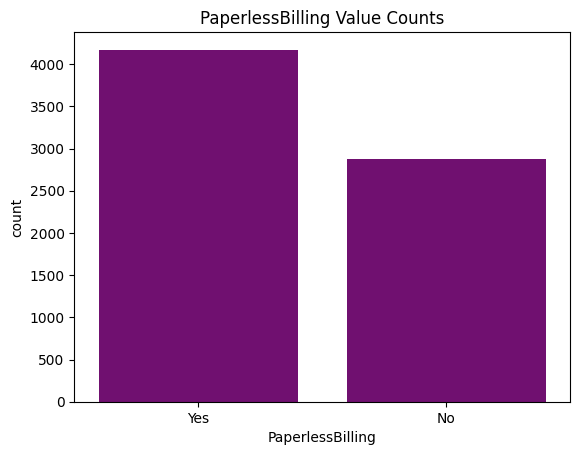

                           PaymentMethod      Ratio
PaymentMethod                                      
Electronic check                    2365  33.579441
Mailed check                        1612  22.887974
Bank transfer (automatic)           1544  21.922476
Credit card (automatic)             1522  21.610109


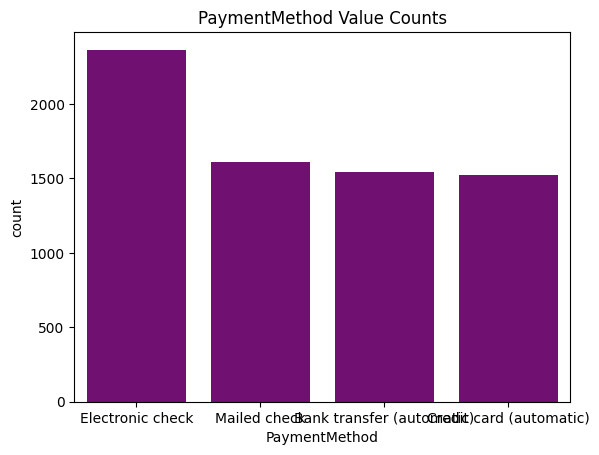

               SeniorCitizen      Ratio
SeniorCitizen                          
0                       5901  83.785319
1                       1142  16.214681


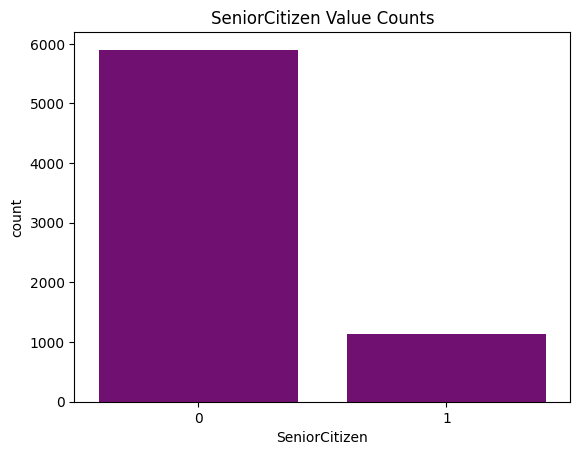

       Churn      Ratio
Churn                  
0       5174  73.463013
1       1869  26.536987


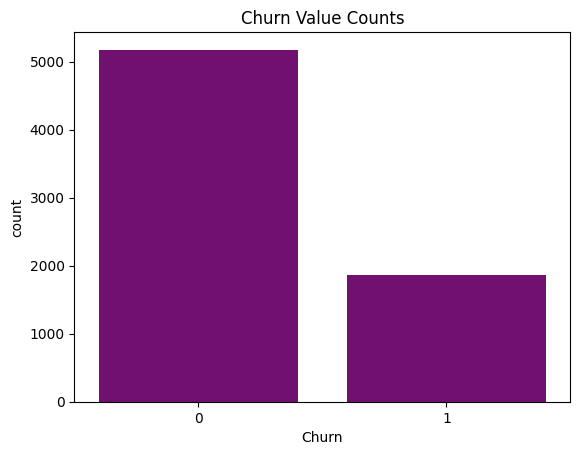

In [15]:
def categorical_cols_summary(dataframe,col_name,plot=True):
  print(pd.DataFrame({col_name:dataframe[col_name].value_counts(),
                      "Ratio": 100*(dataframe[col_name].value_counts()/len(dataframe))}))
  if plot:
    sns.countplot(x=dataframe[col_name],data=dataframe,color='purple')
    plt.title(f"{col_name} Value Counts")
    plt.show()
for col in cat_cols:
  categorical_cols_summary(df,col)

##1.3 ANALYSIS OF NUMERİCAL VARIABLES

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
5%          1.000000
10%         2.000000
20%         6.000000
30%        12.000000
40%        20.000000
50%        29.000000
60%        40.000000
70%        50.000000
80%        60.000000
90%        69.000000
95%        72.000000
99%        72.000000
max        72.000000
Name: tenure, dtype: float64


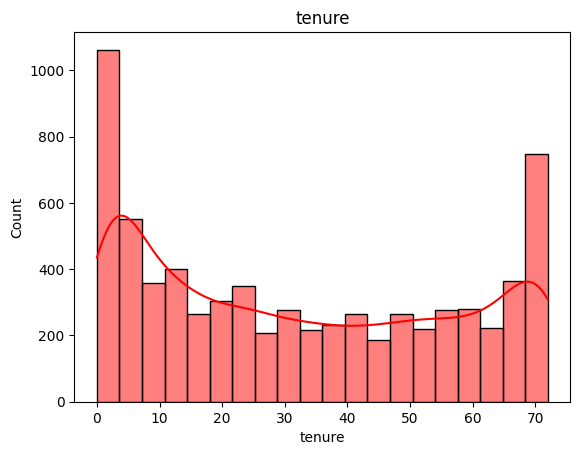

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
5%         19.650000
10%        20.050000
20%        25.050000
30%        45.850000
40%        58.830000
50%        70.350000
60%        79.100000
70%        85.500000
80%        94.250000
90%       102.600000
95%       107.400000
99%       114.729000
max       118.750000
Name: MonthlyCharges, dtype: float64


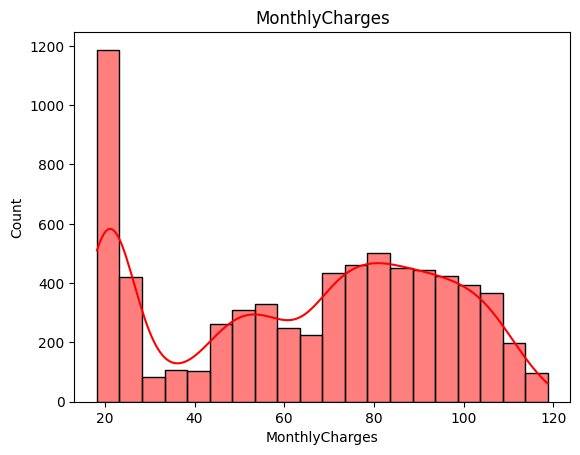

count    7032.000000
mean     2283.300441
std      2266.771362
min        18.800000
5%         49.605000
10%        84.600000
20%       267.070000
30%       551.995000
40%       944.170000
50%      1397.475000
60%      2048.950000
70%      3141.130000
80%      4475.410000
90%      5976.640000
95%      6923.590000
99%      8039.883000
max      8684.800000
Name: TotalCharges, dtype: float64


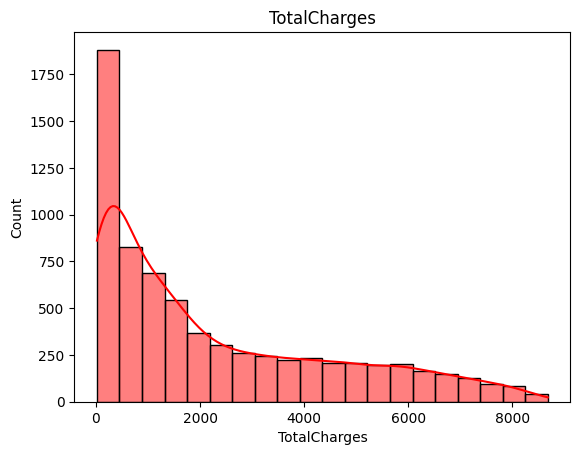

In [16]:
def num_summary(dataframe, numerical_col, plot=True):
    quantiles = [0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95, 0.99]
    print(dataframe[numerical_col].describe(quantiles).T)

    if plot:
        sns.histplot(dataframe[numerical_col], kde=True, bins=20, color='red')
        plt.xlabel(numerical_col)
        plt.title(numerical_col)
        plt.show()

for col in num_cols:
    num_summary(df, col)

##1.4 ANALYSIS OF NUMERICAL VARIABLES BY TARGET

In [17]:
def target_summary_with_num(dataframe, target, numerical_col):
    print(dataframe.groupby(target).agg({numerical_col: "mean"}), end="\n\n\n")
for col in num_cols:
    target_summary_with_num(df, "Churn", col)


          tenure
Churn           
0      37.569965
1      17.979133


       MonthlyCharges
Churn                
0           61.265124
1           74.441332


       TotalCharges
Churn              
0       2555.344141
1       1531.796094




###📊 Key Observations
1️⃣ Tenure:

📉 Customers who churned (left the service) stayed for an average of ~18 months.

📈 Customers who did not churn stayed for an average of ~37.57 months.

👉 **Interpretation**: The longer a customer stays, the less likely they are to churn. Newer customers are more prone to leaving early.



2️⃣ Monthly Charges:

📈 Customers who churned pay a higher average monthly fee of ₹74.44.

📉 Customers who did not churn pay a lower average monthly fee of ₹61.27.

👉 **Interpretation**: Higher charges might be a trigger for customer churn. It suggests pricing sensitivity — customers paying more are leaving more frequently.



3️⃣ Total Charges:

📉 Customers who churned have a lower total amount paid over time ₹1531.80.

📈 Customers who did not churn paid a higher total amount ₹2555.34.

👉 **Interpretation**: Since customers who churned stayed for less time, naturally their total paid is lower. It also means retaining customers longer directly increases revenue.

##1.5 ANALYSIS OF CATEGORICAL VARIABLES BY TARGET

In [18]:
def target_summary_with_cat(dataframe, target, categorical_col):
    print(categorical_col)
    print(pd.DataFrame({"TARGET_MEAN": dataframe.groupby(categorical_col)[target].mean(),
                        "Count": dataframe[categorical_col].value_counts(),
                        "Ratio": 100 * dataframe[categorical_col].value_counts() / len(dataframe)}), end="\n\n\n")

for col in cat_cols:
    target_summary_with_cat(df, "Churn", col)

gender
        TARGET_MEAN  Count     Ratio
gender                              
Female     0.269209   3488  49.52435
Male       0.261603   3555  50.47565


Partner
         TARGET_MEAN  Count     Ratio
Partner                              
No          0.329580   3641  51.69672
Yes         0.196649   3402  48.30328


Dependents
            TARGET_MEAN  Count      Ratio
Dependents                               
No             0.312791   4933  70.041176
Yes            0.154502   2110  29.958824


PhoneService
              TARGET_MEAN  Count      Ratio
PhoneService                               
No               0.249267    682   9.683374
Yes              0.267096   6361  90.316626


MultipleLines
                  TARGET_MEAN  Count      Ratio
MultipleLines                                  
No                   0.250442   3390  48.132898
No phone service     0.249267    682   9.683374
Yes                  0.286099   2971  42.183729


InternetService
                 TARGET_MEAN  Count  

###📊 Key Observations
Churn rate is similar for males and females.

Customers without partners churn significantly more.

Customers without dependents churn twice as much as those with dependents.

Fiber optic internet users have the highest churn rate.

Month-to-month contract customers churn far more than long-term contract holders.

Paperless billing customers churn nearly twice as much as those with paper bills.

Electronic check users have the highest churn rate among payment methods.

Senior citizens churn almost twice as much as non-seniors.

Overall churn rate is around 26.5%.

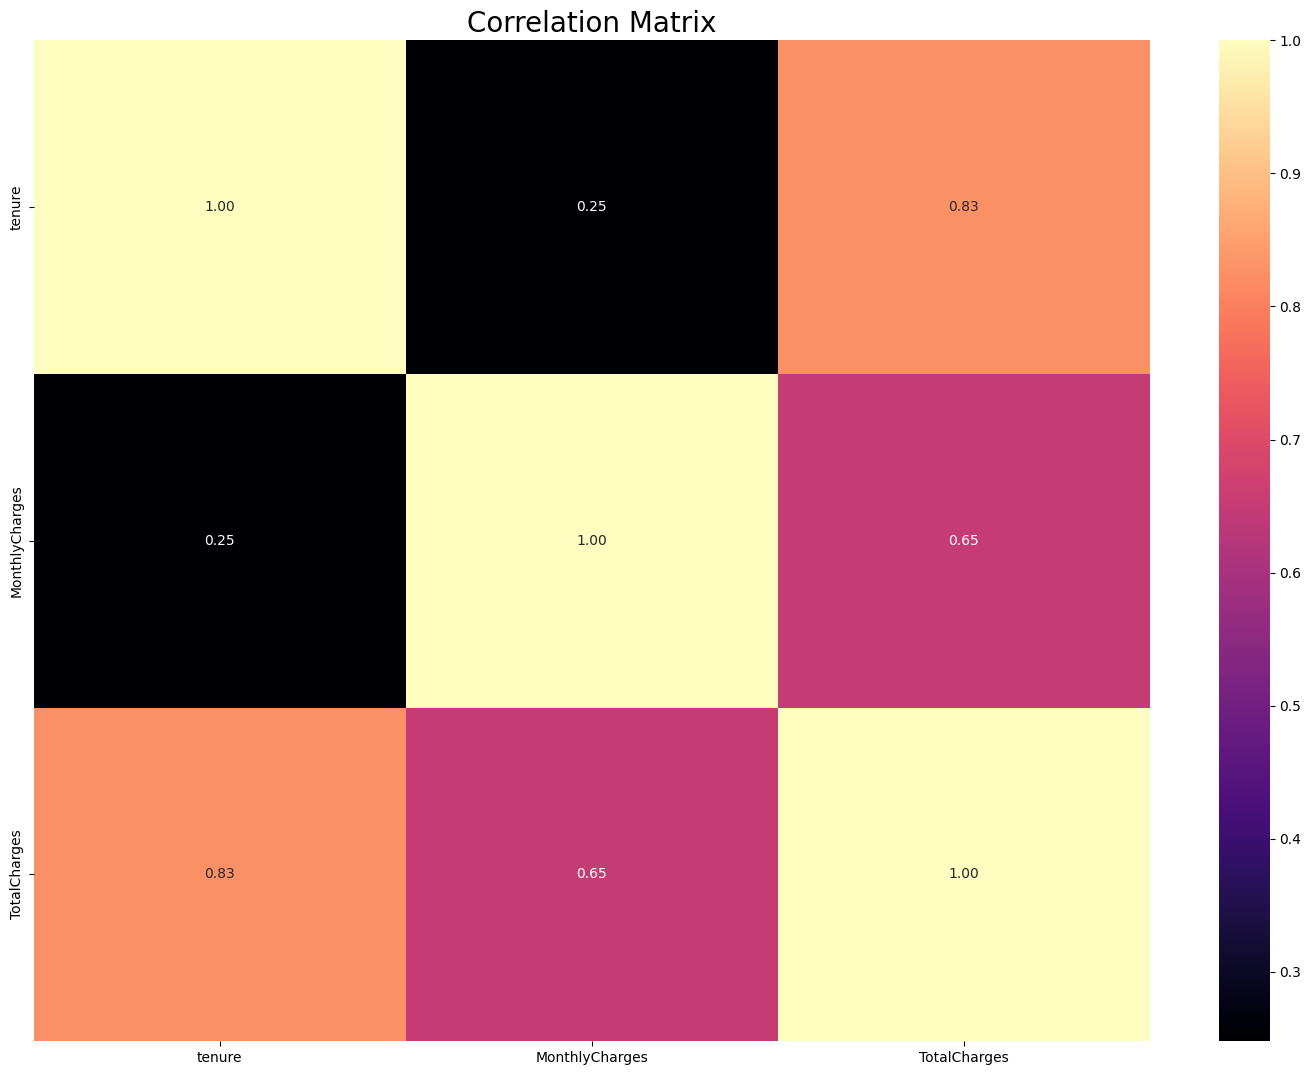

,0
MonthlyCharges,0.193356
TotalCharges,-0.199484
tenure,-0.352229


In [19]:
df[num_cols].corr() # TotalCharges & tenure correlation is 0.825

f, ax = plt.subplots(figsize=[18, 13])
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", ax=ax, cmap="magma")
ax.set_title("Correlation Matrix", fontsize=20)
plt.show()

df[num_cols].corrwith(df["Churn"]).sort_values(ascending=False)

###📊 Key Observations
**MonthlyCharges**	+0.19  Slight positive correlation — higher monthly charges → more likely to churn.

**TotalCharges**	-0.20	  Weak negative correlation — higher total charges → less likely to churn (probably loyal, long-term customers).

**Tenure**	-0.35	Moderate negative correlation — customers with longer tenure are less likely to churn.

##KDE plot

Text(0.5, 1.0, 'Monthly Charges by Churn')

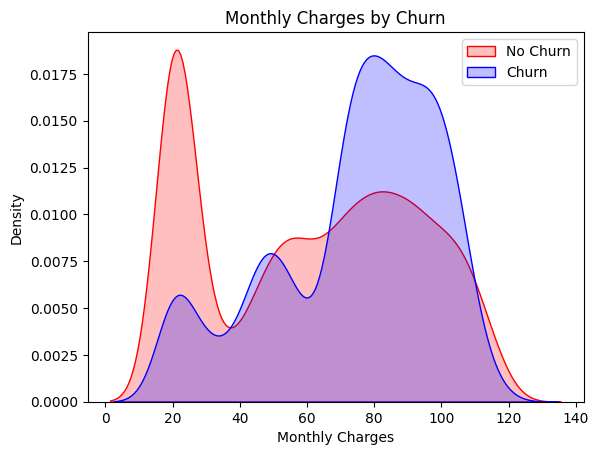

In [20]:
Mth = sns.kdeplot(df["MonthlyCharges"][df["Churn"] == 0],
                  color="Red", fill=True)
Mth = sns.kdeplot(df["MonthlyCharges"][df["Churn"] == 1],
                  ax=Mth, color="Blue", fill=True)
Mth.legend(["No Churn", "Churn"], loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Monthly Charges')
Mth.set_title('Monthly Charges by Churn')


##📊 Key Observation
 Churn is high when Monthly Charges ar high

Text(0.5, 1.0, 'Monthly Charges by Churn')

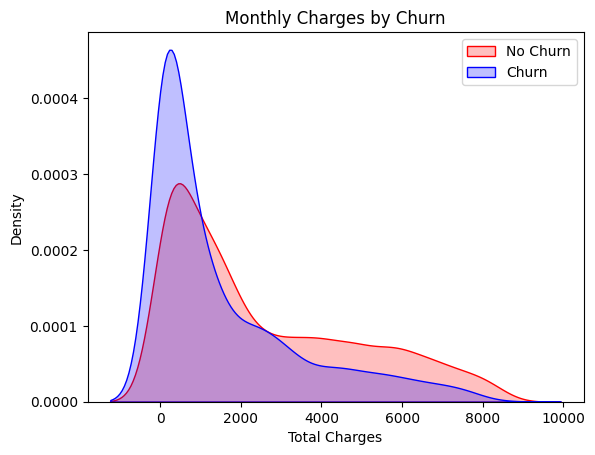

In [21]:
Mth = sns.kdeplot(df["TotalCharges"][df["Churn"] == 0],
                  color="Red", fill=True)
Mth = sns.kdeplot(df["TotalCharges"][df["Churn"] == 1],
                  ax=Mth, color="Blue", fill=True)
Mth.legend(["No Churn", "Churn"], loc='upper right')
Mth.set_ylabel('Density')
Mth.set_xlabel('Total Charges')
Mth.set_title('Monthly Charges by Churn')


##📊 Key Observation
**Surprising Insight:**
Higher churn is observed at lower total charges.

However, when combining the insights from Tenure, Monthly Charges, and Total Charges, the picture becomes clearer:

Higher Monthly Charges combined with Lower Tenure leads to Lower Total Charges.
This trio — Higher Monthly Charges, Lower Tenure, and Lower Total Charges — is closely linked to higher churn probability.

##Missing Value Handling

In [22]:
### 1. Missing Value Handling
# Display records with missing values
print("Records with missing TotalCharges:")
print(df[df['TotalCharges'].isnull()])

# Since these customers have 0 tenure, it makes sense they have no total charges
# We can either drop them or impute with 0
print("\nImputing missing TotalCharges with 0 for customers with 0 tenure:")
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f"Missing values after imputation: {df['TotalCharges'].isnull().sum()}")

Records with missing TotalCharges:
      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
488   4472-LVYGI  Female              0     Yes        Yes       0   
753   3115-CZMZD    Male              0      No        Yes       0   
936   5709-LVOEQ  Female              0     Yes        Yes       0   
1082  4367-NUYAO    Male              0     Yes        Yes       0   
1340  1371-DWPAZ  Female              0     Yes        Yes       0   
3331  7644-OMVMY    Male              0     Yes        Yes       0   
3826  3213-VVOLG    Male              0     Yes        Yes       0   
4380  2520-SGTTA  Female              0     Yes        Yes       0   
5218  2923-ARZLG    Male              0     Yes        Yes       0   
6670  4075-WKNIU  Female              0     Yes        Yes       0   
6754  2775-SEFEE    Male              0      No        Yes       0   

     PhoneService     MultipleLines InternetService       OnlineSecurity  ...  \
488            No  No phone service        

##Outlier Analysis


Outliers in tenure:
Number of outliers: 0
Percentage of outliers: 0.00%
Lower bound: -60.0, Upper bound: 124.0

Outliers in MonthlyCharges:
Number of outliers: 0
Percentage of outliers: 0.00%
Lower bound: -46.02499999999999, Upper bound: 171.375

Outliers in TotalCharges:
Number of outliers: 0
Percentage of outliers: 0.00%
Lower bound: -4683.525, Upper bound: 8868.675


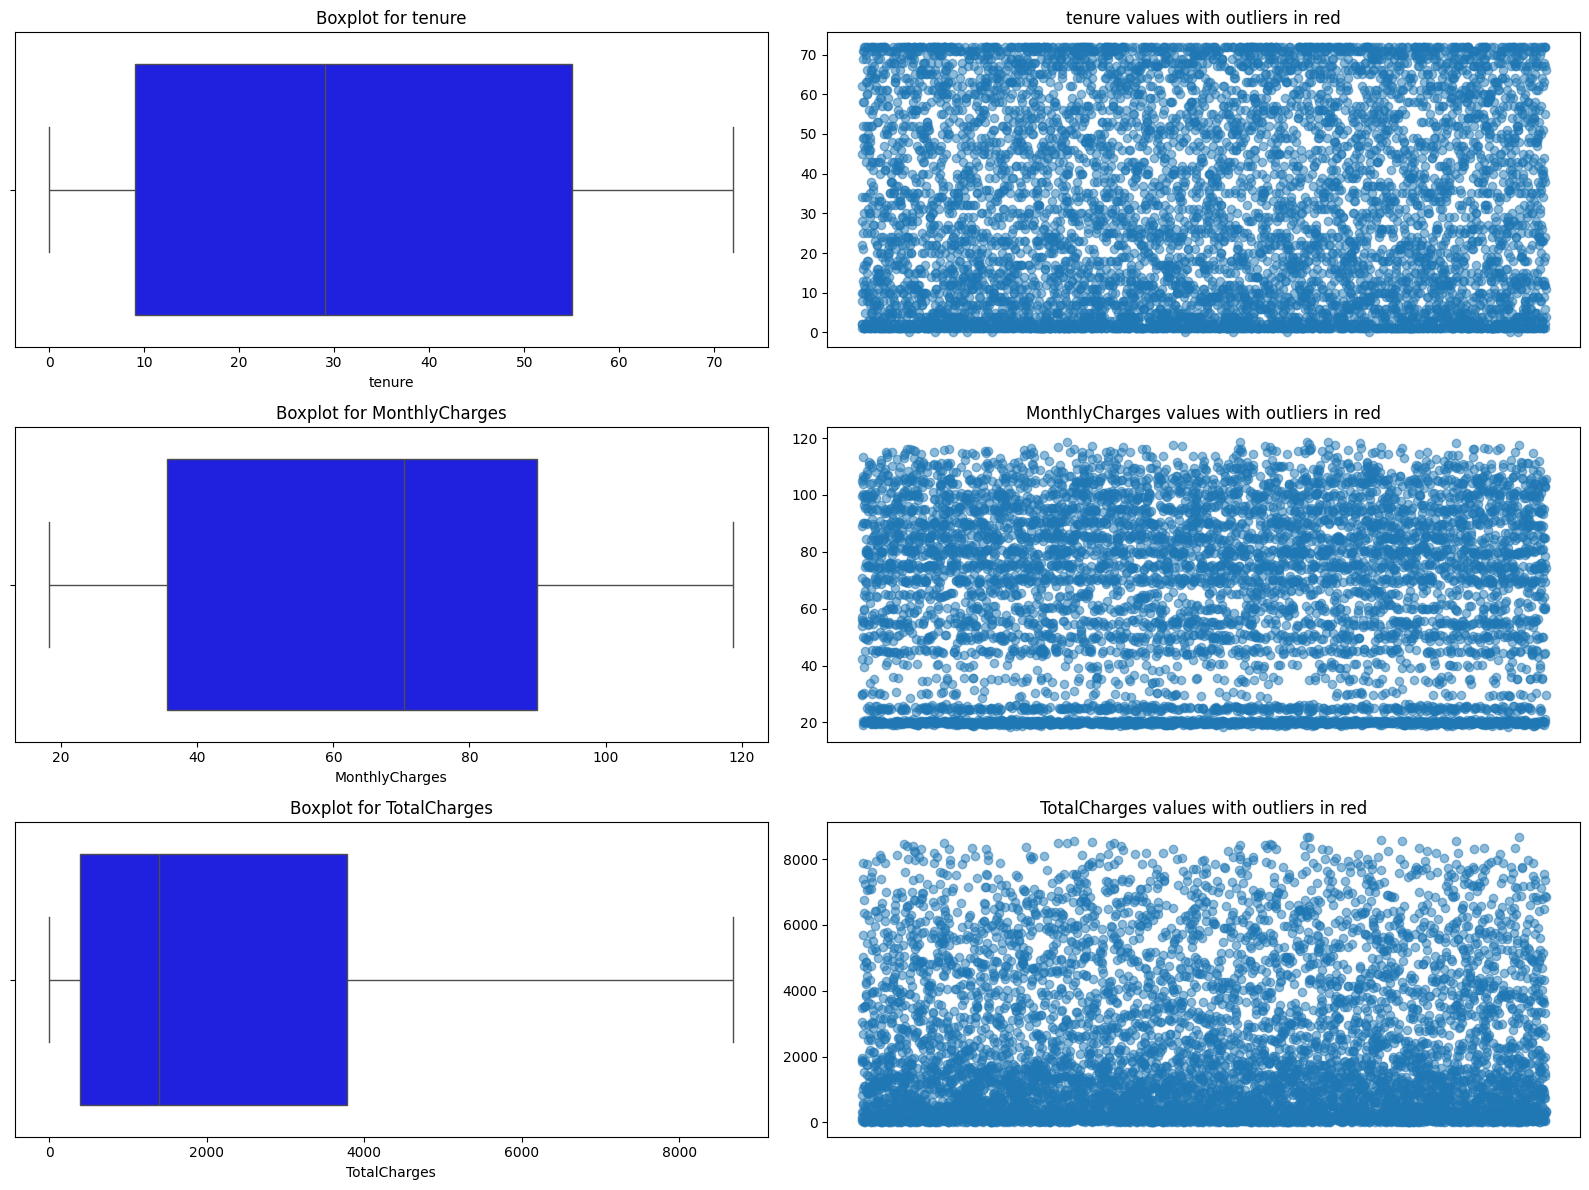

In [23]:
### 2. Outlier Analysis
def detect_outliers(df, cols):
    """
    Detect outliers using IQR method and visualize with boxplots
    """
    plt.figure(figsize=(16, 12))
    for i, col in enumerate(cols):
        plt.subplot(len(cols), 2, (i*2)+1)
        sns.boxplot(x=df[col], color='blue')
        plt.title(f'Boxplot for {col}')

        # Calculate outliers
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

        plt.subplot(len(cols), 2, (i*2)+2)
        plt.scatter(range(len(df)), df[col], alpha=0.5)
        if not outliers.empty:
            plt.scatter(outliers.index, outliers[col], color='red')
        plt.title(f'{col} values with outliers in red')
        plt.xticks([])

        print(f"\nOutliers in {col}:")
        print(f"Number of outliers: {len(outliers)}")
        print(f"Percentage of outliers: {(len(outliers)/len(df))*100:.2f}%")
        print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

    plt.tight_layout()
    plt.show()

# Apply to numerical columns
detect_outliers(df, num_cols)

##📊 Key Observation
**No outliers** were detected in the tenure, MonthlyCharges, or TotalCharges columns based on the IQR (Interquartile Range) method.

**Boxplots** for all three features show a symmetric and well-distributed range of values with no extreme data points.

**Scatter plots** confirm that all data points lie within the expected bounds, with no red points, indicating absence of outliers.

In [24]:

# Investigate if outliers have different churn behavior
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    non_outliers = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

    if not outliers.empty:
        print(f"\nChurn rate comparison for {col}:")
        print(f"Outliers churn rate: {outliers['Churn'].mean()*100:.2f}%")
        print(f"Non-outliers churn rate: {non_outliers['Churn'].mean()*100:.2f}%")



=== Feature Engineering ===


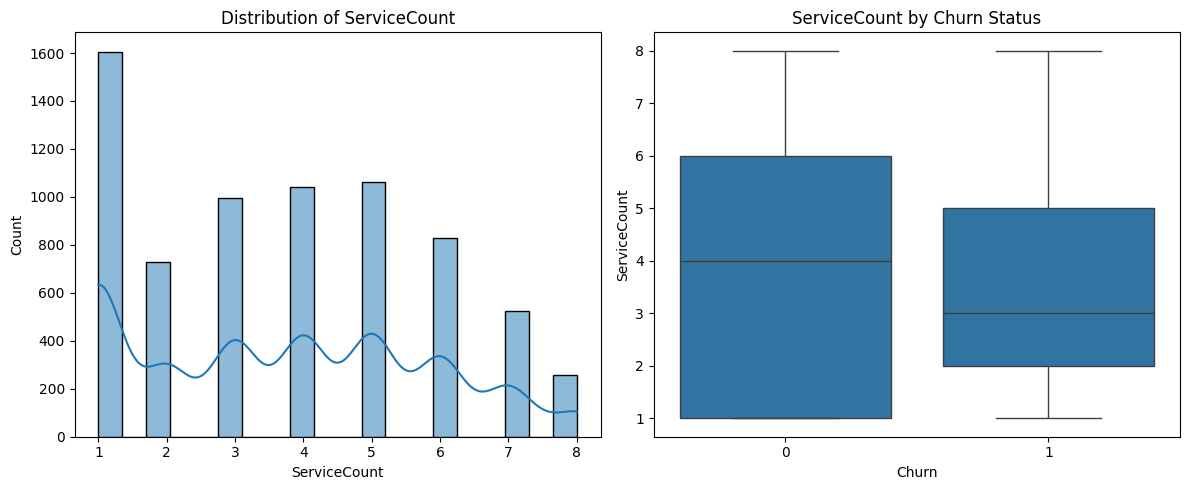


Correlation of ServiceCount with Churn: -0.0308


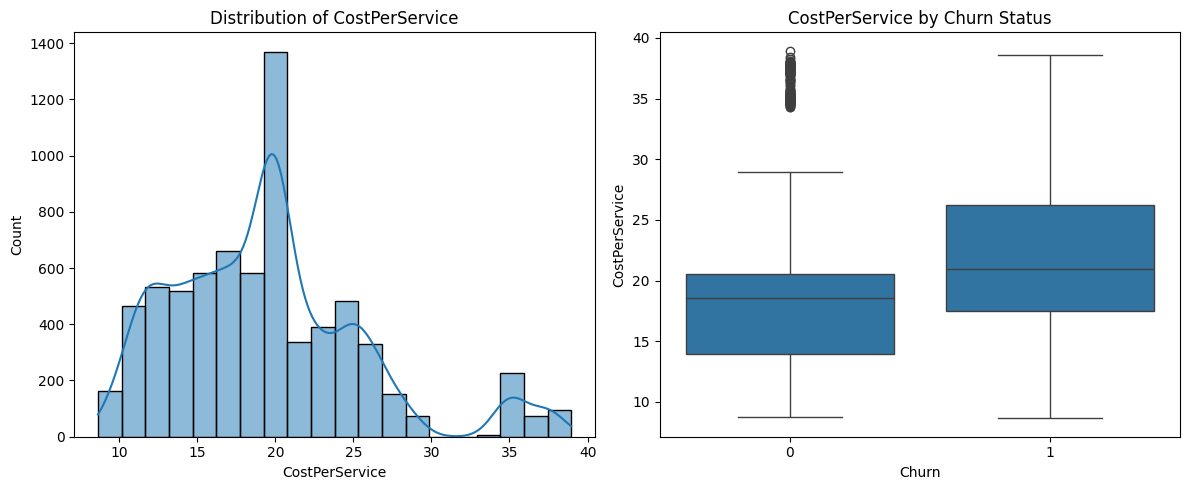


Correlation of CostPerService with Churn: 0.2876


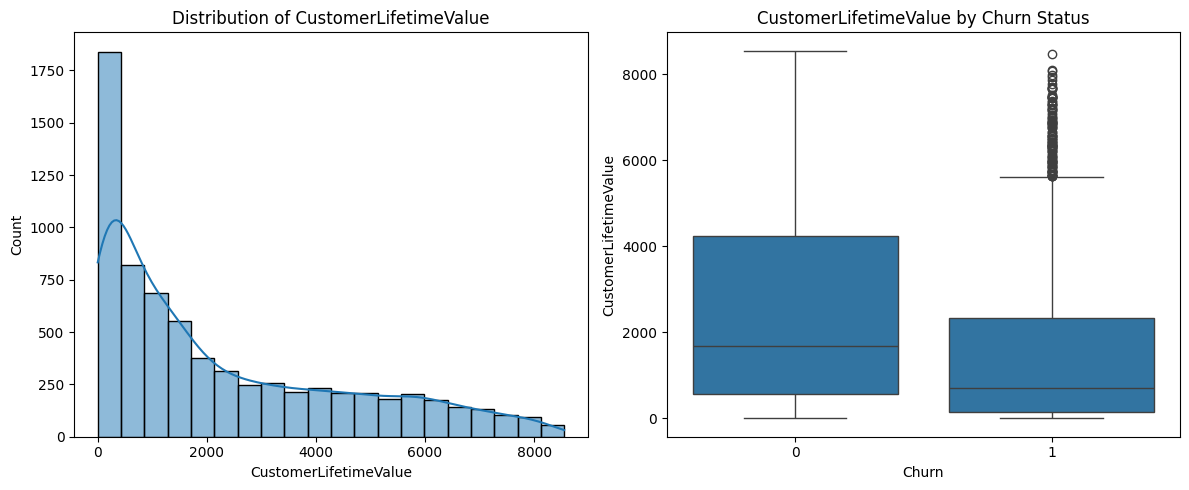


Correlation of CustomerLifetimeValue with Churn: -0.1985


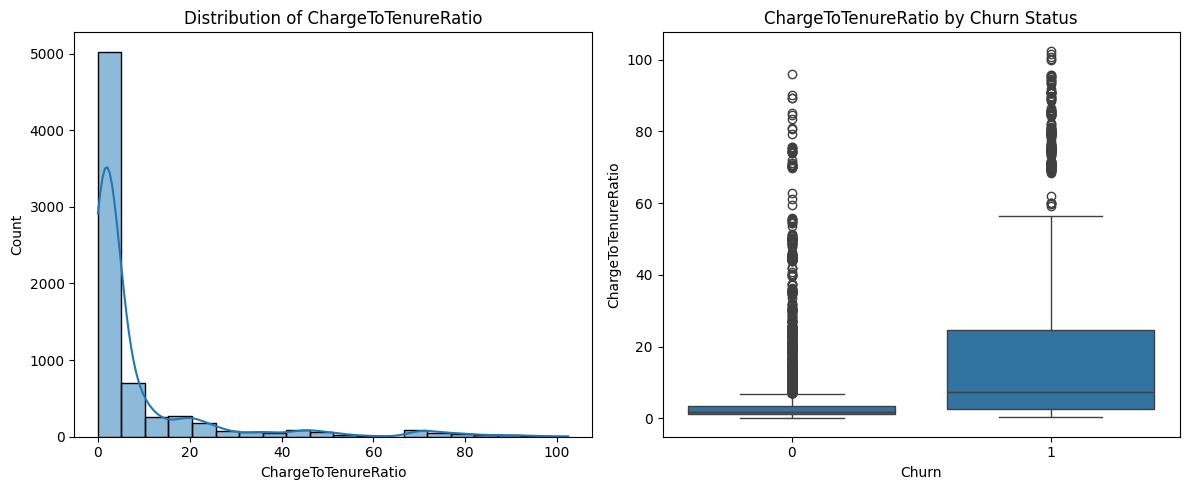


Correlation of ChargeToTenureRatio with Churn: 0.3864


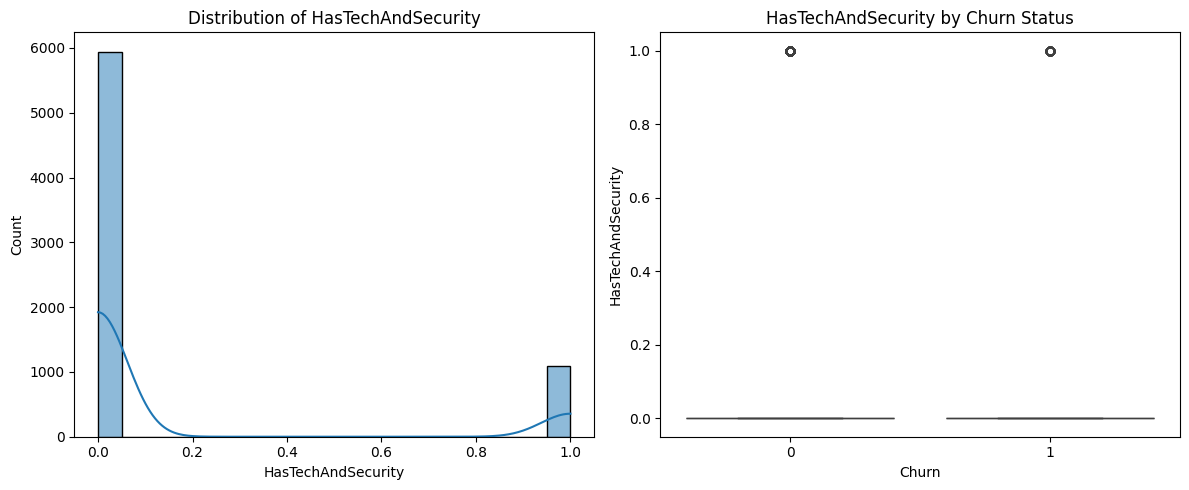


Correlation of HasTechAndSecurity with Churn: -0.1707


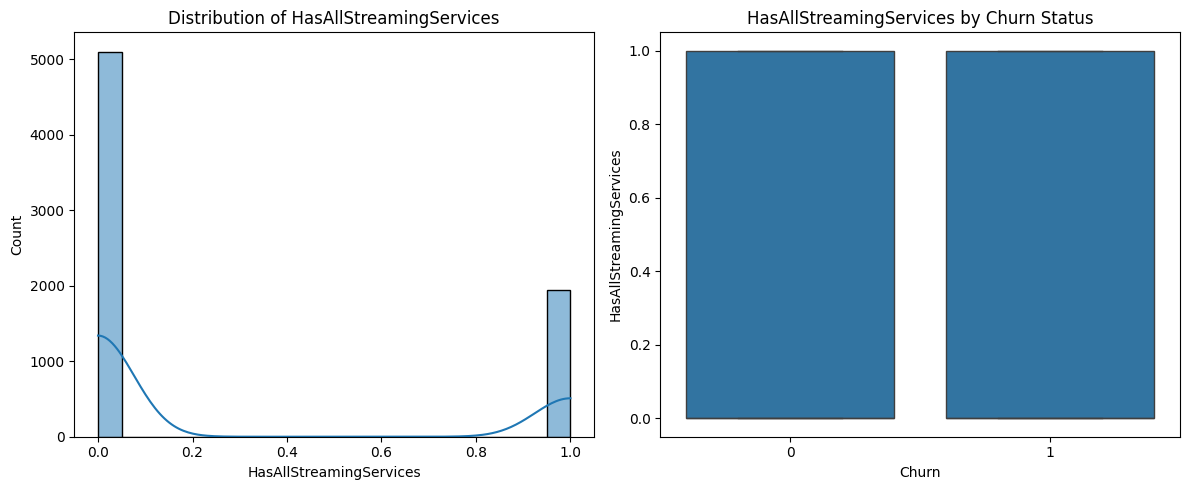


Correlation of HasAllStreamingServices with Churn: 0.0404


In [25]:

### 3. Feature Engineering Exploration
# Create new features that might be predictive
print("\n\n=== Feature Engineering ===")

# 1. Monthly charge per service
# Count services for each customer
service_columns = ['PhoneService', 'InternetService', 'OnlineSecurity',
                  'OnlineBackup', 'DeviceProtection', 'TechSupport',
                  'StreamingTV', 'StreamingMovies']

df['ServiceCount'] = 0
for col in service_columns:
    # Count as service if not 'No' or 'No internet service' or 'No phone service'
    if col == 'InternetService':
        df['ServiceCount'] += df[col].apply(lambda x: 0 if x == 'No' else 1)
    else:
        df['ServiceCount'] += df[col].apply(lambda x: 0 if x in ['No', 'No internet service', 'No phone service'] else 1)

# Calculate cost per service
df['CostPerService'] = df.apply(lambda x: x['MonthlyCharges'] / x['ServiceCount'] if x['ServiceCount'] > 0 else 0, axis=1)

# 2. Customer lifetime value
df['CustomerLifetimeValue'] = df['MonthlyCharges'] * df['tenure']

# 3. Monthly charge to tenure ratio - how much they're paying relative to how long they've been a customer
df['ChargeToTenureRatio'] = df.apply(lambda x: x['MonthlyCharges'] / x['tenure'] if x['tenure'] > 0 else 0, axis=1)

# 4. Categorize tenure into groups
df['TenureGroup'] = pd.qcut(df['tenure'], 4, labels=['0-25%', '25-50%', '50-75%', '75-100%'])

# 5. Binary indicators for key service combinations
df['HasTechAndSecurity'] = ((df['TechSupport'] == 'Yes') & (df['OnlineSecurity'] == 'Yes')).astype(int)
df['HasAllStreamingServices'] = ((df['StreamingTV'] == 'Yes') & (df['StreamingMovies'] == 'Yes')).astype(int)

# Analyze new features
new_features = ['ServiceCount', 'CostPerService', 'CustomerLifetimeValue',
                'ChargeToTenureRatio', 'HasTechAndSecurity', 'HasAllStreamingServices']

for col in new_features:
    if df[col].dtype in ['int64', 'float64']:
        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, bins=20)
        plt.title(f'Distribution of {col}')

        plt.subplot(1, 2, 2)
        sns.boxplot(x='Churn', y=col, data=df)
        plt.title(f'{col} by Churn Status')

        plt.tight_layout()
        plt.show()

        print(f"\nCorrelation of {col} with Churn: {df[col].corr(df['Churn']):.4f}")
    else:
        target_summary_with_cat(df, "Churn", col)


In [26]:
### Statistical Testing
from scipy import stats

print("\n\n=== Statistical Testing ===")

# T-test for numerical variables
for col in num_cols:
    churn_yes = df[df['Churn'] == 1][col]
    churn_no = df[df['Churn'] == 0][col]

    t_stat, p_val = stats.ttest_ind(churn_yes, churn_no, equal_var=False)

    print(f"T-test for {col}:")
    print(f"t-statistic: {t_stat:.4f}")
    print(f"p-value: {p_val:.4f}")
    print(f"Statistically significant difference: {p_val < 0.05}")
    print()

# Chi-square test for categorical variables
for col in cat_cols:
    if col != 'Churn':  # Skip the target variable
        contingency_table = pd.crosstab(df[col], df['Churn'])
        chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

        print(f"Chi-square test for {col}:")
        print(f"chi2 value: {chi2:.4f}")
        print(f"p-value: {p:.4f}")
        print(f"Statistically significant association: {p < 0.05}")
        print()




=== Statistical Testing ===
T-test for tenure:
t-statistic: -34.8238
p-value: 0.0000
Statistically significant difference: True

T-test for MonthlyCharges:
t-statistic: 18.4075
p-value: 0.0000
Statistically significant difference: True

T-test for TotalCharges:
t-statistic: -18.7066
p-value: 0.0000
Statistically significant difference: True

Chi-square test for gender:
chi2 value: 0.4841
p-value: 0.4866
Statistically significant association: False

Chi-square test for Partner:
chi2 value: 158.7334
p-value: 0.0000
Statistically significant association: True

Chi-square test for Dependents:
chi2 value: 189.1292
p-value: 0.0000
Statistically significant association: True

Chi-square test for PhoneService:
chi2 value: 0.9150
p-value: 0.3388
Statistically significant association: False

Chi-square test for MultipleLines:
chi2 value: 11.3304
p-value: 0.0035
Statistically significant association: True

Chi-square test for InternetService:
chi2 value: 732.3096
p-value: 0.0000
Statistically s

##📊 Key Observation
All **numerical features** (tenure, MonthlyCharges, TotalCharges) showed statistically significant differences (p < 0.05), meaning these features differ meaningfully between churned and non-churned groups.

Most **categorical features** (like InternetService, Contract, TechSupport) also showed significant associations with churn.

However, **gender** and **PhoneService** had p-values > 0.05, so they are not significantly linked to churn.

In [27]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,MonthlyCharges,TotalCharges,Churn,ServiceCount,CostPerService,CustomerLifetimeValue,ChargeToTenureRatio,TenureGroup,HasTechAndSecurity,HasAllStreamingServices
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,29.85,29.85,0,2,14.925000,29.85,29.850000,0-25%,0,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,56.95,1889.50,0,4,14.237500,1936.30,1.675000,50-75%,0,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,53.85,108.15,1,4,13.462500,107.70,26.925000,0-25%,0,0
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,42.30,1840.75,0,4,10.575000,1903.50,0.940000,50-75%,1,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,70.70,151.65,1,2,35.350000,141.40,35.350000,0-25%,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,84.80,1990.50,0,7,12.114286,2035.20,3.533333,25-50%,1,1
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,103.20,7362.90,0,6,17.200000,7430.40,1.433333,75-100%,0,1
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,29.60,346.45,0,2,14.800000,325.60,2.690909,25-50%,0,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,74.40,306.60,1,2,37.200000,297.60,18.600000,0-25%,0,0


In [29]:
### Feature Importance Pre-assessment
print("\n\n=== Feature Importance Pre-assessment ===")

# Using Random Forest for feature importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Prepare data for modeling
X = df.drop(['Churn', 'customerID'], axis=1)
y = df['Churn']

# Define preprocessing for numerical and categorical data
numerical_features = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]
categorical_features = [col for col in X.columns if X[col].dtype == 'object']

# Create preprocessing steps for numerical and categorical data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# Create and fit a Random Forest Classifier
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X, y)



=== Feature Importance Pre-assessment ===


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges',
                                                   'ServiceCount',
                                                   'CostPerService',
                                                   'CustomerLifetimeValue',
                                                   'ChargeToTenureRatio',
                                                   'HasTechAndSecurity',
                                                   'HasAllStreamingServices']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [30]:

# Extract feature names after preprocessing
ohe = preprocessor.named_transformers_['cat']
feature_names = numerical_features + list(ohe.get_feature_names_out(categorical_features))

# Get feature importances
importances = rf_pipeline.named_steps['classifier'].feature_importances_

<ipython-input-31-064bc60a2ee8>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')


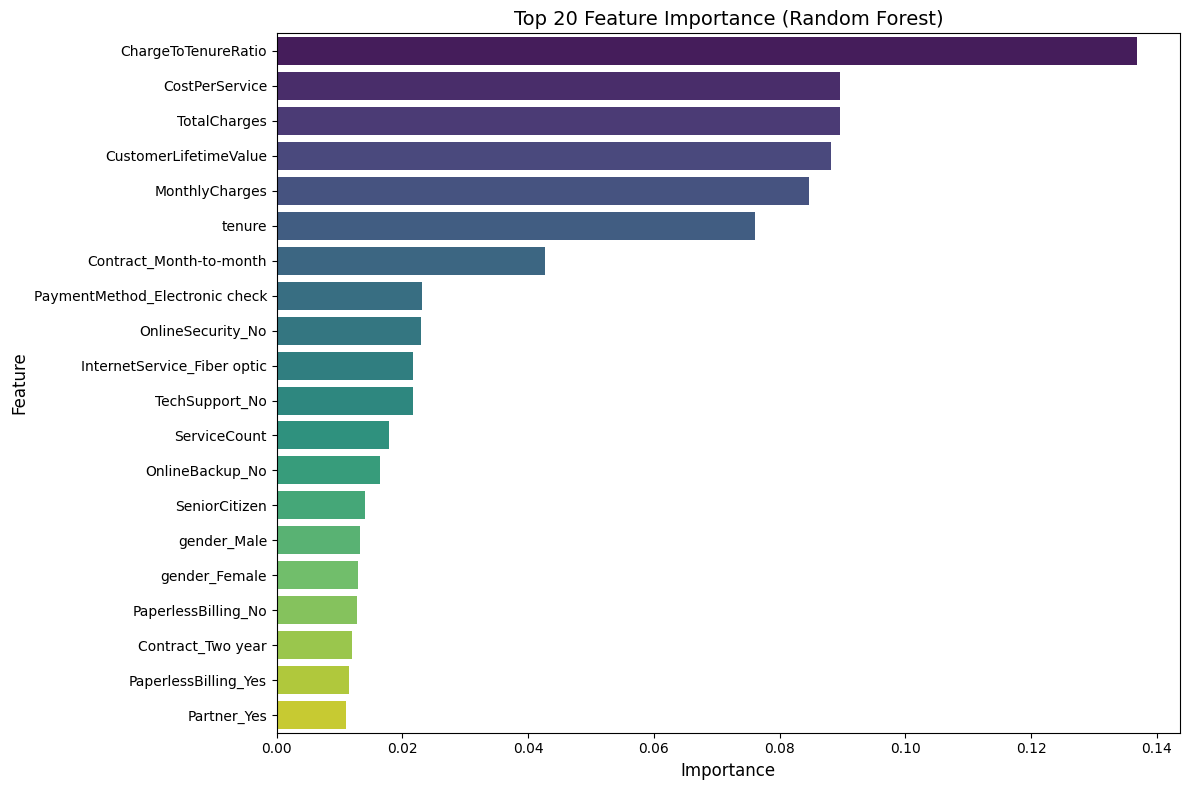

Top 10 most important features:
                           Feature  Importance
7              ChargeToTenureRatio    0.136861
5                   CostPerService    0.089605
3                     TotalCharges    0.089567
6            CustomerLifetimeValue    0.088162
2                   MonthlyCharges    0.084629
1                           tenure    0.076116
42         Contract_Month-to-month    0.042743
49  PaymentMethod_Electronic check    0.023029
24               OnlineSecurity_No    0.022871
22     InternetService_Fiber optic    0.021723


In [31]:
# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importance (Random Forest)', fontsize=14)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("Top 10 most important features:")
print(feature_importance_df.head(10))
